
--- REZULTATI: SVI ATRIBUTI ---
       Algoritam     Score
0         KMeans  0.230919
1      MiniBatch  0.025346
2  Agglomerative  0.383678
3       Spectral  0.235673
4         DBSCAN  0.000000


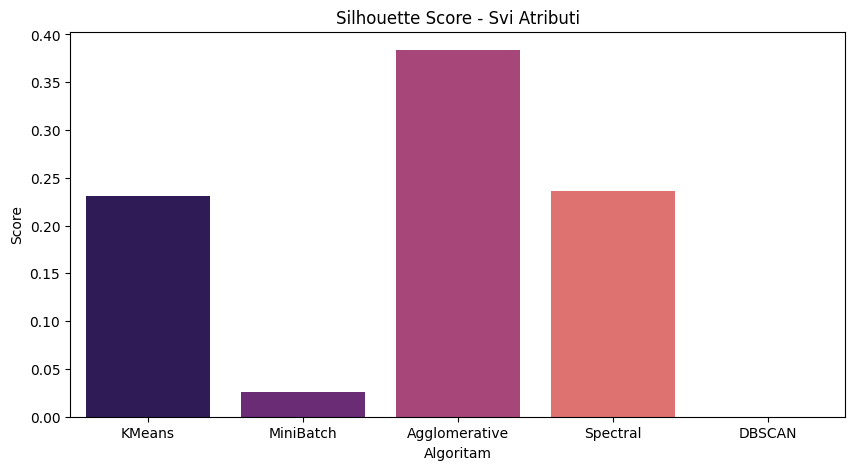

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score

# ccitavanje
df = pd.read_csv("Reviews_sample_balanced.csv").dropna(subset=['Text', 'HelpfulnessNumerator', 'HelpfulnessDenominator']).head(2000)

# tekstualni deo
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_text = tfidf.fit_transform(df['Text']).toarray()

# numericki deo (Helpfulness)
scaler = StandardScaler()
X_num = scaler.fit_transform(df[['HelpfulnessNumerator', 'HelpfulnessDenominator']])

# spajanje (Tekst + Brojevi)
X_all = np.hstack((X_text, X_num))

results = {}

km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_all)
results['KMeans'] = silhouette_score(X_all, km.labels_)

mb = MiniBatchKMeans(n_clusters=5, random_state=42, n_init=10).fit(X_all)
results['MiniBatch'] = silhouette_score(X_all, mb.labels_)

agg = AgglomerativeClustering(n_clusters=5).fit(X_all)
results['Agglomerative'] = silhouette_score(X_all, agg.labels_)

spec = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42).fit(X_all)
results['Spectral'] = silhouette_score(X_all, spec.labels_)

db = DBSCAN(eps=0.5, min_samples=5).fit(X_all)
if len(set(db.labels_)) > 1:
    results['DBSCAN'] = float(silhouette_score(X_all, db.labels_))
else:
    results['DBSCAN'] = 0.0

# Tabela
df_res = pd.DataFrame(list(results.items()), columns=['Algoritam', 'Score'])
df_res['Score'] = pd.to_numeric(df_res['Score'], errors='coerce').fillna(0.0)

print("\n--- REZULTATI: SVI ATRIBUTI ---")
print(df_res)

# Grafik
plt.figure(figsize=(10,5))
sns.barplot(x='Algoritam', y='Score', data=df_res, hue='Algoritam', palette='magma', legend=False)
plt.title('Silhouette Score - Svi Atributi')
plt.show()

In [6]:
df_res.to_csv("rezultati_all.csv", index=False)